# Load and visualize a cave network from the KNdata-public database


For this notebook to work you need to install some package (networkx, et Karstnet-ERC) Karstnet-ERC is a updated package from the Karstnet projet. To import and install the karstnet version on the ERC-Karst/Karstnet-ERC github:

1. clone the repository, 
2. navigate to the repository with command line,
3. ``pip install .``    (the . is part of the command)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

import karstnet as kn

## Load the data

In [ ]:
import pandas as pd
table_caves = pd.read_csv('../caves_fulldatasets/caves_properties_summary.csv', sep=';', index_col=1, dtype={'id_subset':str, 'id_dataset':str})

In [63]:
#load graph
import pandas as pd
#this loads the csv file with all the caves info. 
table_caves = pd.read_csv('../caves_fulldatasets/caves_properties_summary.csv', sep=';', index_col=1, dtype={'id_subset':str, 'id_dataset':str})

#choose your cave here:
cavename = 'GouffreDejaVu'
#this automatically finds the associated ids to find the path to the data
id_dataset = table_caves.loc['GouffreDejaVu']['id_dataset']
id_subset = table_caves.loc['GouffreDejaVu']['id_subset']

#create the string for the path to the data. alternativelly, copy paste the entire path as a string, instead of using automatic ids.
path_to_yaml = f'../caves_fulldatasets/data/{id_dataset}_{cavename}_{id_subset}/{id_dataset}_{cavename}_{id_subset}.yaml'

#load the graph data as a networkx object. 
G = kn.io_func.networkx_from_yaml(path_to_yaml,add_edge_attr=True,add_node_attr=True)


## Access the metadata

In [64]:
#some metadata are attached to the graph. you can access them with:
print(f'id_dataset = {G.graph['id_dataset']}')
print(f'short_name = {G.graph['short_name']}')
print(f'id_subset = {G.graph['id_subset']}')
print(f'status = {G.graph['status']}')
print(f'license = {G.graph['license']}')
print(f'citation = {G.graph['citation']}')
# status = G.graph['status']

#uncomment below to print all the metadata dictionnary
# G.graph

id_dataset = 001
short_name = GouffreDejaVu
id_subset = 000
status = clean
license = CC BY-NC-SA 4.0
citation = Centre Terre. (2024). Survey Data for the Ultima Patagonia Cave Exploration project [Dataset]. https://github.com/tr1813/ultima-patag


## Visualizing the data with Karstnet

The graph can be plotted with the basic function nx.draw(). In the Karstnet package you can find improved plotting function that take into account the position of nodes.

For enhanced visualization tools, check out [Karstnet_plotting.ipynb](https://github.com/ERC-Karst/Karstnet-ERC/blob/main/notebooks/Karstnet_plotting.ipynb)

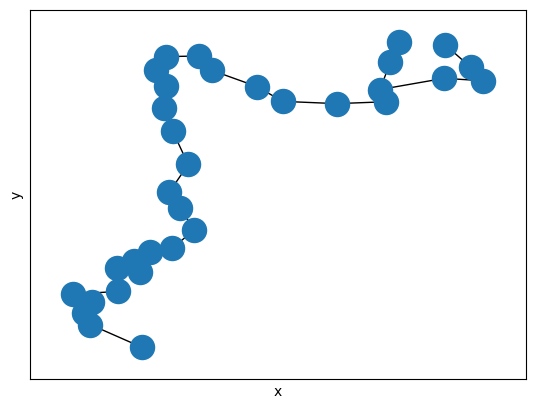

In [65]:
# in 2D
kn.view.plot_graph2d(G)

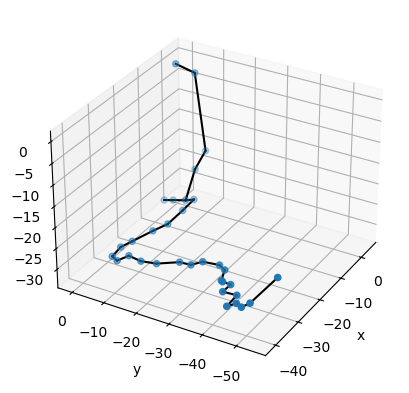

In [66]:
# in 3D
kn.view.plot_graph3d(G)

## Access graph attributes

In [67]:
#If you want to know which attributes are attached to the graph:
# get a list of all the dictionnaries that exists:
print(f'this is the list of attributes attached to the nodes: {kn.utils.get_node_attribute_names(G)}')
print(f'this is the list of attributes attached to the edges: {kn.utils.get_edge_attribute_names(G)}')

this is the list of attributes attached to the nodes: ['fulladdress', 'splays', 'comments', 'csdim', 'idsql', 'pos', 'flags']
this is the list of attributes attached to the edges: []


Cross-sectional dimension attached to the nodes: {17: [2.3, 0.56], 27: [4.43, 1.17], 5: [5.28, 6.76], 24: [3.32, 7.02], 6: [4.01, 4.01], 30: [3.38, 2.94], 9: [2.88, 2.5], 15: [3.01, 1.11], 1: [1.38, 2.3], 25: [3.02, 1.48], 18: [2.36, 1.36], 29: [1.66, 1.15], 13: [1.72, 1.54], 28: [3.95, 1.14], 31: [6.16, 1.56], 32: [1.97, 2.32], 12: [2.53, 2.07], 10: [1.1, 2.22], 21: [2.19, 4.07], 4: [1.61, 4.14], 7: [3.4, 2.9], 20: [2.37, 2.61], 19: [4.85, 5.12], 11: [1.25, 1.33], 8: [0.78, 0.95], 16: [3.21, 7.42], 22: [2.56, 5.6], 14: [1.46, 2.3], 0: [1.16, 3.27], 3: [0.74, 2.81], 26: [1.72, 2.02], 2: [3.51, 5.64], 23: [8.93, 24.62]}


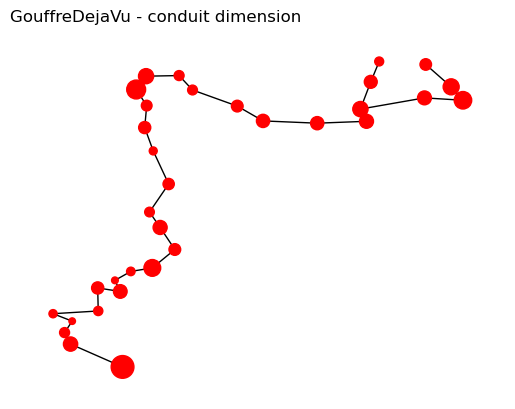

In [68]:
#example to access the attributes:
csdim_dict = nx.get_node_attributes(G,'csdim') #dictionnary of list [width,height]
print(f'Cross-sectional dimension attached to the nodes: {csdim_dict}')

# get the dictionnary of coordinates (x,y,z or x,y)
# pos3d = nx.get_node_attributes(G,'pos')
pos3d = kn.utils.get_pos3d(G) # this function fill set z to 0 in the case the there is only x,y coordinates
pos2d = kn.utils.get_pos2d(G) # this is usefull for plotting 2D

#exemple PLOT WITH WEIGHTED NODE GEOMETRY
node_sizes = []
labels = {}
for n in G.nodes:
    if G.nodes('csdim')[n] is not None:
        node_sizes.append( nx.get_node_attributes(G,'csdim')[n][0]*30 )
    else:
        node_sizes.append( 0.0 )

plt.figure()
ax = plt.gca()
ax.set_title(f'{cavename} - conduit dimension', loc='left',ha='left', wrap=True )
nx.draw(G,kn.utils.get_pos2d(G),node_size=node_sizes ,with_labels=False, node_color='red', ax=ax)

todo?
- geometry
- splays

- flag / use only portion of the graph

- store attributes / save graph

